# Customer Segmentation Using RFM Analysis and K-Means

This notebook analyzes an online retail transaction dataset to understand customer purchasing behavior.

**Workflow**
1. Load and inspect the transaction data
2. Clean the data and create revenue
3. Build customer-level **Recency, Frequency, Monetary (RFM)** measures
4. Explore purchasing behavior with visualizations
5. Prepare and standardize RFM data
6. Use the Elbow Method and Silhouette Score to select a suitable number of clusters
7. Apply K-Means clustering
8. Profile customer segments
9. Generate practical business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
print("Shape:", df.shape)
display(df.head())


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# Basic structure and data quality
display(df.info())
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,missing
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



Duplicate rows: 5268


## 1. Data Cleaning

The analysis uses:
- `InvoiceNo` to identify transactions
- `StockCode` and `Description` for products
- `Quantity` and `UnitPrice` for sales value
- `InvoiceDate` for purchase timing
- `CustomerID` for customer-level analysis
- `Country` for geographic exploration

Cancelled invoices are excluded because they do not represent completed purchases. Rows with missing customer IDs are removed for RFM segmentation because they cannot be assigned to a customer.

In [3]:
# Convert date and remove unusable records
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Standardize text fields
if "Description" in df.columns:
    df["Description"] = df["Description"].astype("string").str.strip()

# Remove rows without essential customer/transaction fields
df_clean = df.dropna(subset=["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"]).copy()

# Exclude cancellations/returns represented by invoice numbers beginning with C
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")].copy()

# Keep positive quantities and prices for completed sales
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

# Create revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Customers:", df_clean["CustomerID"].nunique())
print("Invoices:", df_clean["InvoiceNo"].nunique())
display(df_clean.head())


Original rows: 541909
Clean rows: 397884
Customers: 4338
Invoices: 18532


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


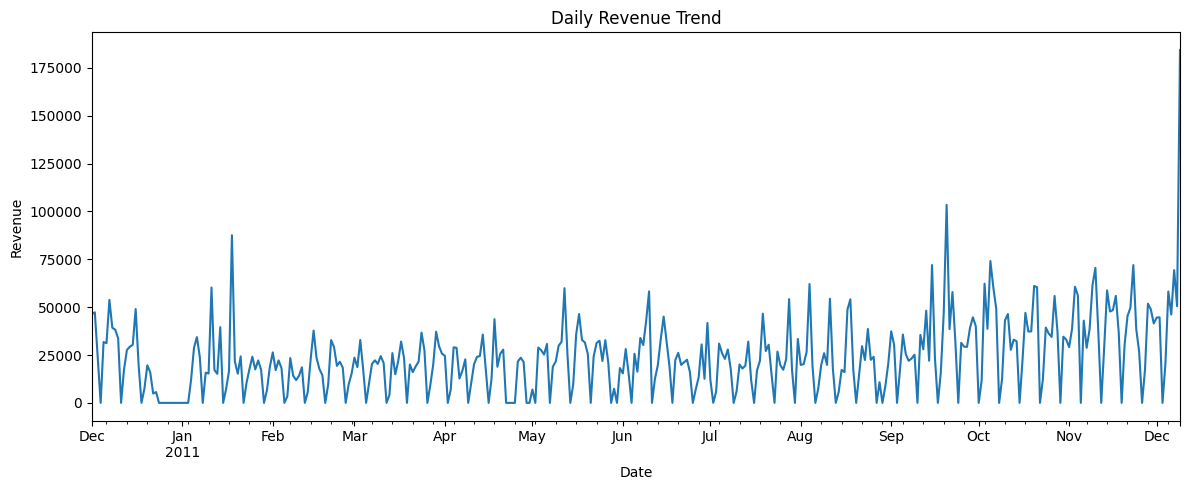

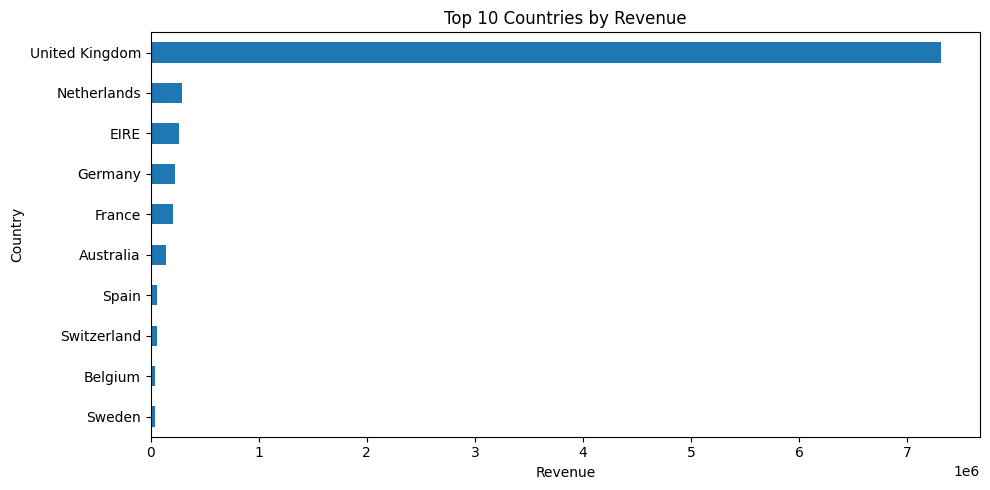

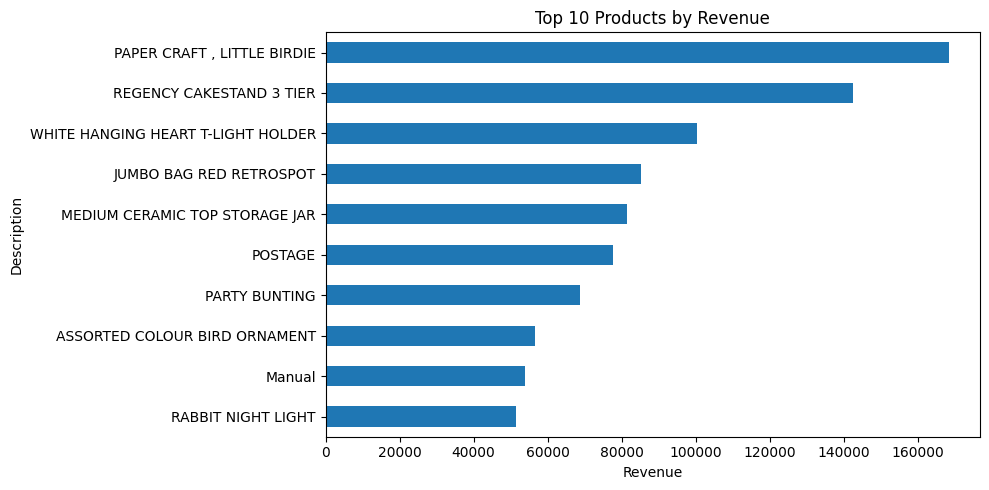

In [4]:
# Exploratory analysis
daily_sales = df_clean.set_index("InvoiceDate")["Revenue"].resample("D").sum()

plt.figure(figsize=(12, 5))
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

country_sales = (df_clean.groupby("Country")["Revenue"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

plt.figure(figsize=(10, 5))
country_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

top_products = (df_clean.groupby("Description")["Revenue"]
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(10, 5))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


## 2. Customer-Level RFM Analysis

RFM measures summarize customer behavior:

- **Recency:** number of days since the customer's most recent purchase. Lower is better.
- **Frequency:** number of unique invoices/purchases made by the customer. Higher is better.
- **Monetary:** total revenue generated by the customer. Higher is better.

The reference date is one day after the latest transaction in the cleaned dataset.

In [5]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (df_clean.groupby("CustomerID")
       .agg(
           Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
           Frequency=("InvoiceNo", "nunique"),
           Monetary=("Revenue", "sum")
       )
       .reset_index())

print("RFM customers:", len(rfm))
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)


RFM customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


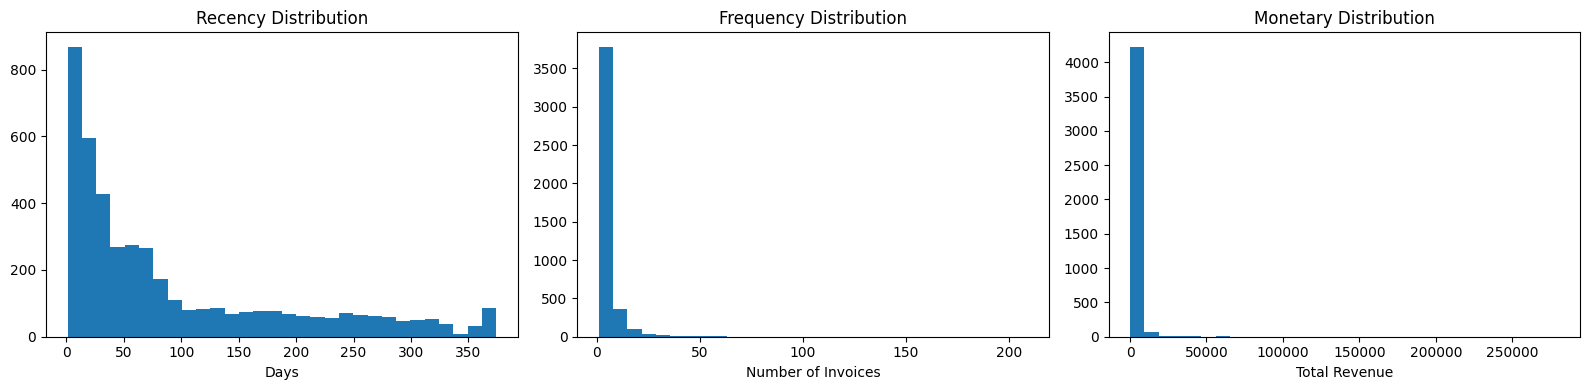

In [6]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins=30)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")

axes[1].hist(rfm["Frequency"], bins=30)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Invoices")

axes[2].hist(rfm["Monetary"], bins=30)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Revenue")

plt.tight_layout()
plt.show()


## 3. Prepare RFM Data for Clustering

RFM variables are usually highly skewed, especially monetary value and frequency. A log transformation reduces the impact of extreme values, then `StandardScaler` puts all variables on a comparable scale.

For Recency, the interpretation is reversed so that higher transformed values represent more desirable recent activity.

In [7]:
rfm_model = rfm.copy()

# Log-transform positive RFM variables
rfm_model["Recency_log"] = np.log1p(rfm_model["Recency"])
rfm_model["Frequency_log"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary_log"] = np.log1p(rfm_model["Monetary"])

# Reverse recency so a higher score means more recent purchasing
rfm_model["Recency_score"] = -rfm_model["Recency_log"]

features = ["Recency_score", "Frequency_log", "Monetary_log"]

scaler = StandardScaler()
X = scaler.fit_transform(rfm_model[features])

print("Feature matrix shape:", X.shape)


Feature matrix shape: (4338, 3)


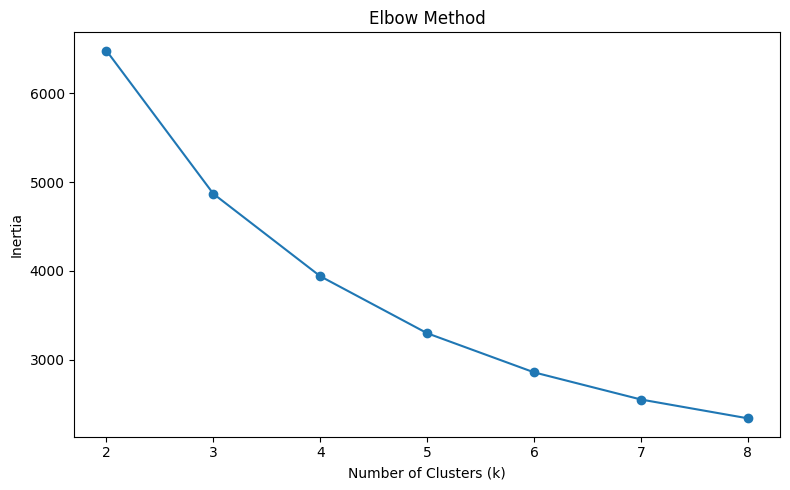

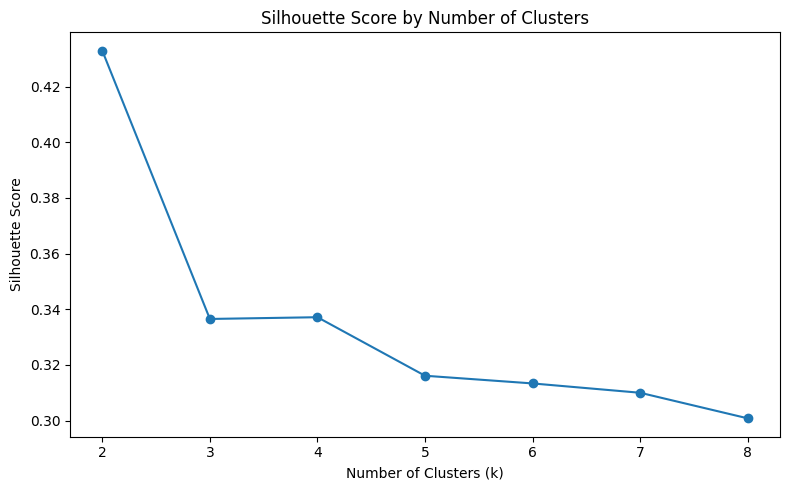

,k,inertia,silhouette_score
0,2,6481.225323,0.432940
1,3,4867.846645,0.336510
2,4,3938.509954,0.337134
3,5,3295.976329,0.316097
4,6,2855.011247,0.313329
5,7,2548.914324,0.309975
6,8,2336.777508,0.300782


In [8]:
# Elbow Method and Silhouette Score
k_values = range(2, 9)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouettes, marker="o")
ax.set_title("Silhouette Score by Number of Clusters")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

score_table = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouettes
})
display(score_table)


### Selecting the number of clusters

Use both plots together:
- The **Elbow Method** looks for a point where additional clusters provide diminishing improvement.
- The **Silhouette Score** measures how well-separated and internally coherent the clusters are.

The code below automatically selects the `k` with the highest silhouette score from the tested range. If the elbow suggests a nearby value, that value can be chosen manually by changing `chosen_k`.

In [9]:
chosen_k = int(score_table.loc[score_table["silhouette_score"].idxmax(), "k"])
print("Selected k based on highest silhouette score:", chosen_k)

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
rfm_model["Cluster"] = kmeans.fit_predict(X)

# Attach labels to original RFM table
rfm_segmented = rfm_model[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster"]].copy()
display(rfm_segmented.head())


Selected k based on highest silhouette score: 2


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,1
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,0


In [10]:
# Segment profile
segment_profile = (rfm_segmented.groupby("Cluster")
                   .agg(
                       Customers=("CustomerID", "count"),
                       Avg_Recency=("Recency", "mean"),
                       Avg_Frequency=("Frequency", "mean"),
                       Avg_Monetary=("Monetary", "mean"),
                       Total_Revenue=("Monetary", "sum")
                   )
                   .sort_values("Avg_Monetary", ascending=False))

segment_profile["Customer_%"] = segment_profile["Customers"] / len(rfm_segmented) * 100
display(segment_profile.round(2))


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_%
Cluster,,,,,,
1,1667,25.88,8.44,4548.26,7581946.78,38.43
0,2671,134.14,1.67,497.74,1329461.12,61.57


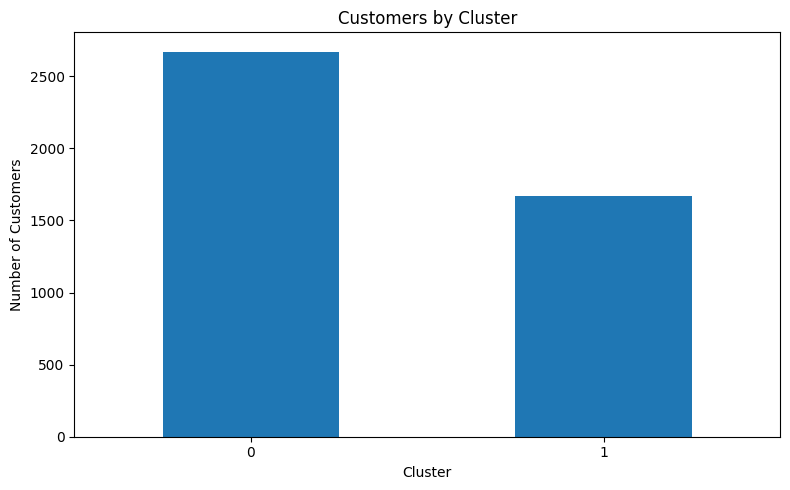

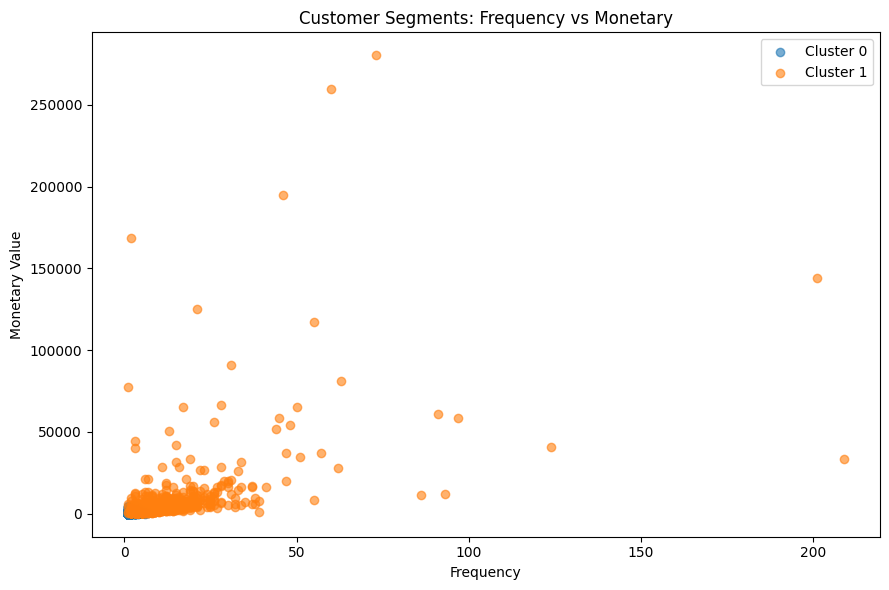

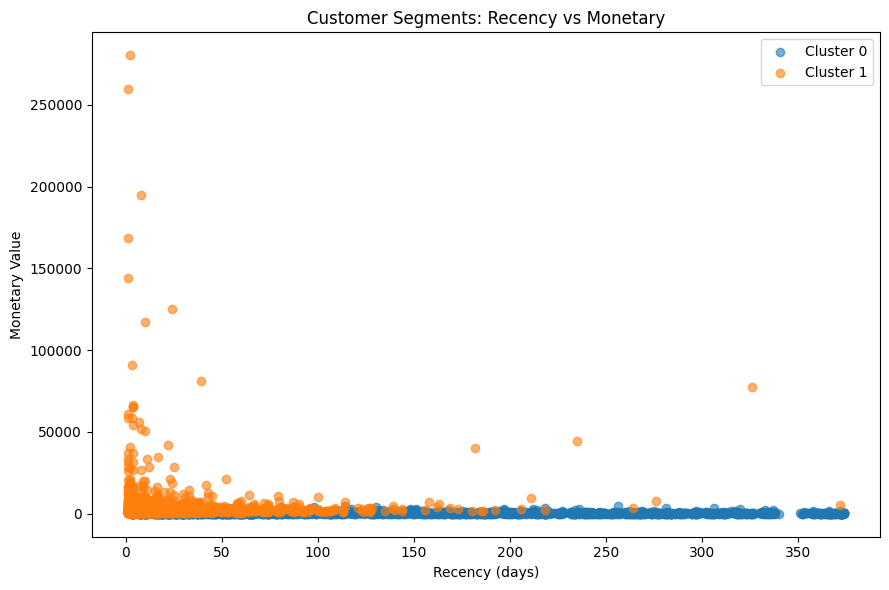

In [11]:
# Visualize cluster sizes
cluster_counts = rfm_segmented["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")
plt.title("Customers by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Frequency vs Monetary
plt.figure(figsize=(9, 6))
for cluster in sorted(rfm_segmented["Cluster"].unique()):
    subset = rfm_segmented[rfm_segmented["Cluster"] == cluster]
    plt.scatter(subset["Frequency"], subset["Monetary"], label=f"Cluster {cluster}", alpha=0.6)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend()
plt.tight_layout()
plt.show()

# Recency vs Monetary
plt.figure(figsize=(9, 6))
for cluster in sorted(rfm_segmented["Cluster"].unique()):
    subset = rfm_segmented[rfm_segmented["Cluster"] == cluster]
    plt.scatter(subset["Recency"], subset["Monetary"], label=f"Cluster {cluster}", alpha=0.6)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Segment Interpretation and Business Recommendations

Cluster numbers are arbitrary, so segment names should be assigned from the observed RFM profile rather than from the numeric cluster ID.

The following rules provide a practical automatic interpretation:
- **Champions / VIP:** low recency, high frequency, high monetary value
- **Loyal Customers:** relatively recent and frequent purchases with solid spending
- **Potential Loyalists:** recent customers with moderate frequency/spending
- **At-Risk / Hibernating:** high recency with lower activity
- **Other:** remaining customers

The exact labels depend on the resulting cluster profiles.

In [12]:
# Relative RFM rankings for interpretation
ranked = segment_profile.copy()
ranked["Recency_rank"] = ranked["Avg_Recency"].rank(ascending=True)
ranked["Frequency_rank"] = ranked["Avg_Frequency"].rank(ascending=False)
ranked["Monetary_rank"] = ranked["Avg_Monetary"].rank(ascending=False)

def label_segment(row):
    recent = row["Recency_rank"] <= max(1, chosen_k / 2)
    high_freq = row["Frequency_rank"] <= max(1, chosen_k / 2)
    high_money = row["Monetary_rank"] <= max(1, chosen_k / 2)

    if recent and high_freq and high_money:
        return "Champions / VIP"
    if recent and high_freq:
        return "Loyal Customers"
    if recent:
        return "Potential Loyalists"
    if high_money:
        return "High-Value At-Risk"
    return "At-Risk / Hibernating"

ranked["Segment"] = ranked.apply(label_segment, axis=1)

display(ranked[[
    "Customers", "Customer_%", "Avg_Recency",
    "Avg_Frequency", "Avg_Monetary", "Total_Revenue", "Segment"
]].round(2))


,Customers,Customer_%,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Segment
Cluster,,,,,,,
1,1667,38.43,25.88,8.44,4548.26,7581946.78,Champions / VIP
0,2671,61.57,134.14,1.67,497.74,1329461.12,At-Risk / Hibernating


In [13]:
# Practical recommendations based on segment profile
recommendations = {
    "Champions / VIP": [
        "Provide VIP rewards, early access, and exclusive offers.",
        "Use personalized cross-sell and upsell recommendations.",
        "Protect loyalty with premium service and retention benefits."
    ],
    "Loyal Customers": [
        "Use loyalty points, bundles, and personalized recommendations.",
        "Encourage higher basket value through cross-sells.",
        "Reward repeat purchasing with tiered benefits."
    ],
    "Potential Loyalists": [
        "Use welcome-to-loyalty campaigns and product recommendations.",
        "Offer limited-time incentives to increase purchase frequency.",
        "Promote complementary products based on previous purchases."
    ],
    "High-Value At-Risk": [
        "Run targeted win-back campaigns quickly.",
        "Offer personalized incentives rather than broad discounts.",
        "Use email reminders and recommendations based on past purchases."
    ],
    "At-Risk / Hibernating": [
        "Test low-cost reactivation campaigns.",
        "Use personalized discounts or reminders to encourage a return.",
        "Avoid excessive marketing spend if response rates remain low."
    ]
}

for cluster, row in ranked.iterrows():
    print(f"Cluster {cluster} — {row['Segment']}")
    for rec in recommendations[row["Segment"]]:
        print(" •", rec)
    print()


Cluster 1 — Champions / VIP
 • Provide VIP rewards, early access, and exclusive offers.
 • Use personalized cross-sell and upsell recommendations.
 • Protect loyalty with premium service and retention benefits.

Cluster 0 — At-Risk / Hibernating
 • Test low-cost reactivation campaigns.
 • Use personalized discounts or reminders to encourage a return.
 • Avoid excessive marketing spend if response rates remain low.



## 5. Export the Customer Segmentation Results

The final customer-level file contains RFM measures and the assigned K-Means cluster. It can be used for CRM, marketing campaigns, dashboards, or further predictive modeling.

In [14]:
output_file = "customer_rfm_kmeans_segments.csv"
rfm_segmented.to_csv(output_file, index=False)
print(f"Saved: {output_file}")
display(rfm_segmented.sort_values("Monetary", ascending=False).head(10))


Saved: customer_rfm_kmeans_segments.csv


,CustomerID,Recency,Frequency,Monetary,Cluster
1689,14646.0,2,73,280206.02,1
4201,18102.0,1,60,259657.30,1
3728,17450.0,8,46,194550.79,1
3008,16446.0,1,2,168472.50,1
1879,14911.0,1,201,143825.06,1
55,12415.0,24,21,124914.53,1
1333,14156.0,10,55,117379.63,1
3771,17511.0,3,31,91062.38,1
2702,16029.0,39,63,81024.84,1
0,12346.0,326,1,77183.60,1


## Conclusion

This analysis converts raw transaction data into actionable customer segments using RFM analysis and K-Means clustering. The resulting segments can help a business prioritize retention of high-value customers, reactivate customers who have become inactive, and increase purchase frequency and basket size among developing customer groups.

**Key business use cases**
- Customer retention and churn-risk campaigns
- VIP and loyalty programs
- Personalized product recommendations
- Targeted discounts and win-back campaigns
- Marketing budget prioritization
